<a href="https://colab.research.google.com/github/Koroteika/University/blob/main/Tasks/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%968_%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D1%81_%D0%B2%D0%B5%D0%BA%D1%82%D0%BE%D1%80%D0%BD%D1%8B%D0%BC%D0%B8_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D0%BC%D0%B8_%D0%B2_GeoPandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №2. Работа с векторными данными в GeoPandas**

In [ ]:
%%capture
!pip install geopandas leafmap mapclassify # Устанавливаем библиотеку GeoPandas и необходимые зависимости

## **Задание №1. Операции с массивами NumPy и геопространственными координатами**


1. Создайте двумерный массив NumPy, содержащий широту и долготу следующих городов: Токио (35.6895, 139.6917), Нью-Йорк (40.7128, -74.0060), Лондон (51.5074, -0.1278) и Париж (48.8566, 2.3522).


In [ ]:
# Ваш код
import numpy as np
matrix_cities = np.array([[35.6895, 139.6917],[40.7128, -74.0060],[51.5074, -0.1278],[48.8566, 2.3522]])
matrix_cities

array([[ 3.568950e+01,  1.396917e+02],
       [ 4.071280e+01, -7.400600e+01],
       [ 5.150740e+01, -1.278000e-01],
       [ 4.885660e+01,  2.352200e+00]])

2. Преобразуйте значения широты и долготы из градусов в радианы с помощью функции np.radians().


In [ ]:
# Ваш код
matrix_cities_rad=np.radians(matrix_cities)
matrix_cities_rad

array([[ 6.22899283e-01,  2.43808010e+00],
       [ 7.10572408e-01, -1.29164837e+00],
       [ 8.98973719e-01, -2.23053078e-03],
       [ 8.52708531e-01,  4.10536347e-02]])



3. Рассчитайте поэлементную разницу между координатами Токио и других городов в радианах.

In [ ]:
# Ваш код
tokio = matrix_cities_rad[0]
diff=matrix_cities_rad[1::] - tokio

diff

array([[ 0.08767312, -3.72972847],
       [ 0.27607444, -2.44031063],
       [ 0.22980925, -2.39702647]])

## **Задание 2. Операции с DataFrame Pandas и геопространственными данными**


1. Загрузите набор данных о городах мира по следующему URL с помощью Pandas: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv


In [2]:
# Ваш код
import pandas as pd
df_loader=pd.read_csv('/world_cities.csv', encoding='utf-8')
df_loader

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.58330,32.53330,75000
1,2,Fort Portal,UGA,0.67100,30.27500,42670
2,3,Potenza,ITA,40.64200,15.79900,69060
3,4,Campobasso,ITA,41.56300,14.65600,50762
4,5,Aosta,ITA,45.73700,7.31500,34062
...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000
1247,1248,Singapore,SGP,1.29303,103.85582,5183700


2. Отобразите первые 5 строк и проверьте наличие отсутствующих значений.


In [12]:
# Ваш код
# df_loader.head(5) - отображение первых 5 строк
print(df_loader.head(5), '\n') # первые 5 строк таблицы
print(df_loader.head(5).isnull().sum()) # сумма пропусков



   id         name country  latitude  longitude  population
0   1        Bombo     UGA    0.5833    32.5333       75000
1   2  Fort Portal     UGA    0.6710    30.2750       42670
2   3      Potenza     ITA   40.6420    15.7990       69060
3   4   Campobasso     ITA   41.5630    14.6560       50762
4   5        Aosta     ITA   45.7370     7.3150       34062 

id            0
name          0
country       0
latitude      0
longitude     0
population    0
dtype: int64


3. Отфильтруйте набор данных, чтобы включить только города с населением более 1 миллиона человек.


In [15]:
# Ваш код
large_cities=df_loader[df_loader['population']>1000000]

,id,name,country,latitude,longitude,population
97,98,Turin,ITA,45.07039,7.66996,1652000
103,104,Lille,FRA,50.64997,3.08001,1044000
123,124,San Bernardino,USA,34.12038,-117.30003,1745000
124,125,Bridgeport,USA,41.17998,-73.19996,1018000
126,127,Manchester,GBR,53.50042,-2.24799,2230000
...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000
1247,1248,Singapore,SGP,1.29303,103.85582,5183700


4. Сгруппируйте города по странам и рассчитайте общую численность населения для каждой страны.


In [17]:
# Ваш код
country_population=df_loader.groupby('country')['population'].sum()
country_population

,population
country,
AFG,4931702
AGO,6821544
ALB,895350
ALD,10682
AND,53998
...,...
WSM,61916
YEM,3759000
ZAF,13373789




5. Отсортируйте города по населению в порядке убывания и отобразите первые 10 городов.

In [20]:
# Ваш код
sorted_cities=df_loader.sort_values(by='population', ascending=False)
sorted_cities.head(10)

,id,name,country,latitude,longitude,population
1239,1240,Tokyo,JPN,35.68502,139.75141,35676000
1224,1225,New York,USA,40.74998,-73.98002,19040000
1230,1231,Mexico City,MEX,19.44244,-99.13099,19028000
1240,1241,Mumbai,IND,19.01699,72.85699,18978000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1148,1149,Delhi,IND,28.66999,77.23000,15926000
1238,1239,Shanghai,CHN,31.21645,121.43650,14987000
1243,1244,Kolkata,IND,22.49497,88.32468,14787000
1175,1176,Dhaka,BGD,23.72306,90.40858,12797394
1217,1218,Buenos Aires,ARG,-34.60250,-58.39753,12795000


## **Задание №3. Создание и обработка GeoDataFrames с помощью GeoPandas**


1. Загрузите набор данных о зданиях Нью-Йорка из файла GeoJSON с помощью GeoPandas: https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson

In [23]:
# Ваш код
import geopandas as gpd
buildings_ny=gpd.read_file('/nyc_buildings.geojson')
buildings_ny

,fid,height_MS,height_FM,height_avg,SQMETERS,STATEFP,NAME,geometry
0,2,15.05,23.30,19.18,6365.72,36,New York,"POLYGON ((-74.00129 40.71992, -74.00061 40.719..."
1,4,23.62,46.18,34.90,3287.84,36,New York,"POLYGON ((-74.0032 40.71654, -74.00265 40.7163..."
2,5,19.98,109.60,64.79,2011.21,36,New York,"POLYGON ((-74.01415 40.70324, -74.01342 40.703..."
3,9,18.50,18.18,18.34,3110.32,36,New York,"POLYGON ((-73.98974 40.71924, -73.98924 40.720..."
4,34,21.53,32.84,27.18,5240.89,36,New York,"POLYGON ((-74.00941 40.72351, -74.00816 40.723..."
...,...,...,...,...,...,...,...,...
1201,9764,26.54,22.30,24.42,696.24,36,New York,"POLYGON ((-73.97463 40.72411, -73.97467 40.724..."
1202,9765,10.44,16.53,13.48,2859.96,36,New York,"POLYGON ((-73.98495 40.71911, -73.98436 40.718..."
1203,9766,10.44,13.87,12.16,2859.96,36,New York,"POLYGON ((-73.98495 40.71911, -73.98436 40.718..."
1204,9774,13.76,NaN,13.76,1612.84,36,New York,"POLYGON ((-73.99154 40.71045, -73.99173 40.710..."


2. Создайте график контуров зданий и раскрасьте их в зависимости от высоты здания (используйте столбец `height_MS`).


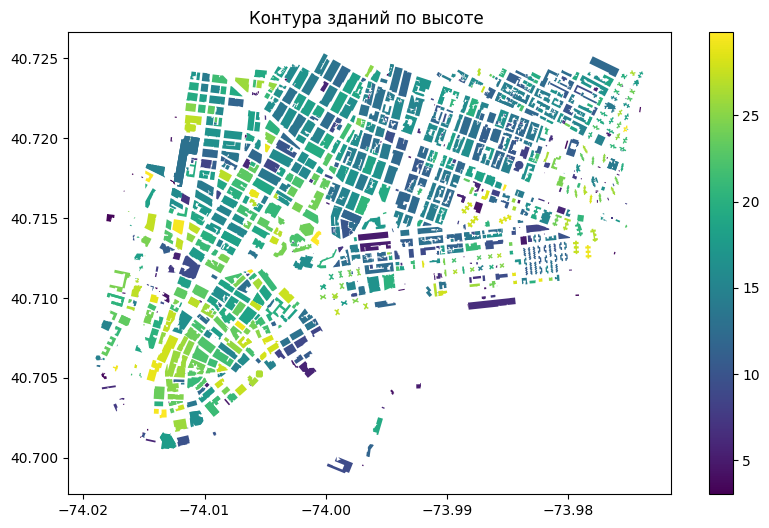

In [27]:
# Ваш код
import matplotlib.pyplot as plt
buildings_ny.plot(column='height_MS', legend=True, figsize=(10,6))

plt.title('Контура зданий по высоте ')
plt.show()

3. Создайте интерактивную карту контуров зданий и раскрасьте их в зависимости от высоты здания (используйте столбец `height_MS`).


In [30]:
# Ваш код
buildings_ny.explore(column="height_MS", cmap="viridis", legend=True, tooltip=["height_MS"],)

4. Рассчитайте среднюю высоту зданий (используйте столбец `height_MS`).


In [32]:
# Ваш код
mean_heigth = buildings_ny['height_MS'].mean()
mean_heigth

np.float64(15.454691136974038)

5. Выберите здания с высотой, превышающей среднюю высоту.


In [35]:
# Ваш код
filter_buildings=buildings_ny[buildings_ny['height_MS'] > mean_heigth]
filter_buildings

,fid,height_MS,height_FM,height_avg,SQMETERS,STATEFP,NAME,geometry
1,4,23.62,46.18,34.90,3287.84,36,New York,"POLYGON ((-74.0032 40.71654, -74.00265 40.7163..."
2,5,19.98,109.60,64.79,2011.21,36,New York,"POLYGON ((-74.01415 40.70324, -74.01342 40.703..."
3,9,18.50,18.18,18.34,3110.32,36,New York,"POLYGON ((-73.98974 40.71924, -73.98924 40.720..."
4,34,21.53,32.84,27.18,5240.89,36,New York,"POLYGON ((-74.00941 40.72351, -74.00816 40.723..."
5,38,18.84,NaN,18.84,1151.88,36,New York,"POLYGON ((-74.01574 40.70672, -74.01537 40.706..."
...,...,...,...,...,...,...,...,...
1196,9714,19.90,19.15,19.52,1230.57,36,New York,"POLYGON ((-73.98328 40.71861, -73.9826 40.7184..."
1198,9752,19.35,NaN,19.35,4080.25,36,New York,"POLYGON ((-73.99528 40.70245, -73.99568 40.702..."
1199,9754,24.11,47.47,35.79,7137.13,36,New York,"POLYGON ((-74.00084 40.71547, -74.00075 40.715..."
1200,9756,16.20,15.17,15.68,166.41,36,New York,"POLYGON ((-73.99054 40.71271, -73.99045 40.712..."





6. Сохраните GeoDataFrame в новый файл GeoJSON.

In [38]:
# Ваш код
filter_buildings.to_file('filter_mean_buildings.geojson',driver='GeoJSON')

## **Задание №4. Применение NumPy, Pandas и GeoPandas для обработки и анализа пространственных данных**


1. Используйте Pandas для загрузки набора данных о городах мира по следующему URL: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv


In [42]:
# Ваш код
pd_cities=pd.read_csv('/content/world_cities (1).csv')
pd_cities

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.58330,32.53330,75000
1,2,Fort Portal,UGA,0.67100,30.27500,42670
2,3,Potenza,ITA,40.64200,15.79900,69060
3,4,Campobasso,ITA,41.56300,14.65600,50762
4,5,Aosta,ITA,45.73700,7.31500,34062
...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000
1247,1248,Singapore,SGP,1.29303,103.85582,5183700


2. Отфильтруйте набор данных, чтобы включить только города с широтой между -40 и 60 (т.е. города, расположенные в Северном полушарии или вблизи экватора).


In [52]:
# Ваш код
filter_cities_conitional=(pd_cities['latitude']>=-40) & (pd_cities['latitude']<=60)
filter_cities=pd_cities[filter_cities_conitional]
filter_cities

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.58330,32.53330,75000
1,2,Fort Portal,UGA,0.67100,30.27500,42670
2,3,Potenza,ITA,40.64200,15.79900,69060
3,4,Campobasso,ITA,41.56300,14.65600,50762
4,5,Aosta,ITA,45.73700,7.31500,34062
...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000
1247,1248,Singapore,SGP,1.29303,103.85582,5183700


3. Создайте GeoDataFrame из отфильтрованного набора данных, преобразовав широту и долготу в геометрии.


In [115]:
# Ваш код
geometry = gpd.points_from_xy(filter_cities['longitude'], filter_cities['latitude'])
gdp_cities=gpd.GeoDataFrame(filter_cities, geometry=geometry,crs="EPSG:4326")
gdp_cities

,id,name,country,latitude,longitude,population,geometry
0,1,Bombo,UGA,0.58330,32.53330,75000,POINT (32.5333 0.5833)
1,2,Fort Portal,UGA,0.67100,30.27500,42670,POINT (30.275 0.671)
2,3,Potenza,ITA,40.64200,15.79900,69060,POINT (15.799 40.642)
3,4,Campobasso,ITA,41.56300,14.65600,50762,POINT (14.656 41.563)
4,5,Aosta,ITA,45.73700,7.31500,34062,POINT (7.315 45.737)
...,...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000,POINT (-43.22502 -22.92502)
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000,POINT (-46.62502 -23.55868)
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000,POINT (151.18518 -33.92001)
1247,1248,Singapore,SGP,1.29303,103.85582,5183700,POINT (103.85582 1.29303)


4. Перепроецируйте GeoDataFrame в проекцию Меркатора (EPSG:3857).


In [116]:
# Ваш код
gdp_cities_m=gdp_cities.to_crs("EPSG:3857")

5. Рассчитайте расстояние (в метрах) между каждым городом и Парижем.


In [121]:
# Ваш код
paris_m = gdp_cities_m[gdp_cities_m['name'] == 'Paris'].iloc[0]
paris_point = paris_m.geometry
gdp_cities['dist_to_paris_m'] = gdp_cities_m.geometry.distance(paris_point, align=False)
gdp_cities



,id,name,country,latitude,longitude,population,geometry,dist_to_paris_m
0,1,Bombo,UGA,0.58330,32.53330,75000,POINT (32.5333 0.5833),7.041672e+06
1,2,Fort Portal,UGA,0.67100,30.27500,42670,POINT (30.275 0.671),6.916454e+06
2,3,Potenza,ITA,40.64200,15.79900,69060,POINT (15.799 40.642),1.979335e+06
3,4,Campobasso,ITA,41.56300,14.65600,50762,POINT (14.656 41.563),1.794231e+06
4,5,Aosta,ITA,45.73700,7.31500,34062,POINT (7.315 45.737),7.561058e+05
...,...,...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000,POINT (-43.22502 -22.92502),1.022204e+07
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000,POINT (-46.62502 -23.55868),1.048050e+07
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000,POINT (151.18518 -33.92001),1.949483e+07
1247,1248,Singapore,SGP,1.29303,103.85582,5183700,POINT (103.85582 1.29303),1.284655e+07




6. Отобразите города на карте мира, раскрасив точки в зависимости от их расстояния до Парижа.

In [122]:
# Ваш код
gdp_cities.crs
gdp_cities.explore(column="dist_to_paris_m", cmap="viridis", legend=True, tooltip=["name", "dist_to_paris_m"])